# Efficiency and Fairness per model

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Classes.bar import Bar
from Config.config import PATHS

In [2]:
def plot_stability(list_of_alternations, list_of_titles, num_rounds):
	fig, axes = plt.subplots(len(list_of_alternations))
	for i, alternations in enumerate(list_of_alternations):
		# Detect number of agents
		num_agents = len(alternations[0])
		# Create bar object
		bar = Bar(
			num_agents=num_agents,
			threshold=0.5
		)
		bar.history = alternations * (num_rounds // len(alternations)) + alternations[:num_rounds % len(alternations)]
		attendance_file_name = None #'alternations.png'
		bar.render(
			ax=axes[i],
			file=attendance_file_name,
			num_rounds=len(bar.history)
		)
#		axes[i].imshow(plt.imread(attendance_file_name))
		if list_of_titles is not None:
			axes[i].set_title(list_of_titles[i])
		axes[i].axis('off')
	return fig


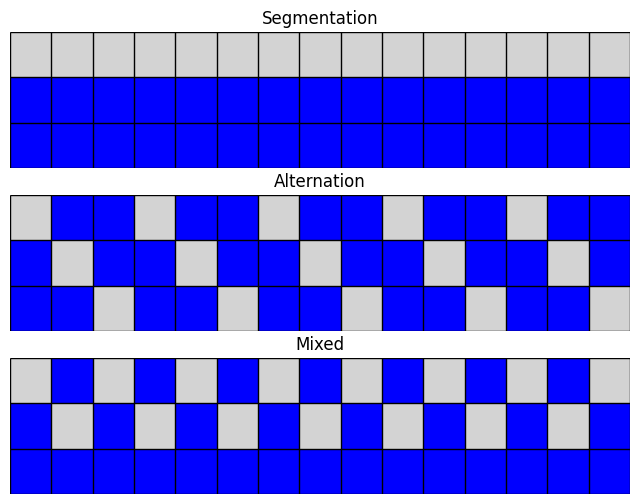

In [3]:
num_rounds = 15
list_of_alternations = [
	# [np.random.randint(0, 2, 3).tolist() for _ in range(num_rounds)],
	[[1, 1, 0]],
	[[1, 1, 0], [1, 0, 1], [0, 1, 1]],
#	[[0, 0, 1], [0, 1, 0], [1, 0, 0]],
	[[1, 1, 0], [1, 0, 1]],
]
fig = plot_stability(
    list_of_alternations=list_of_alternations, 
    list_of_titles = ['Segmentation', 'Alternation', 'Mixed'],
#    list_of_titles = ['Segmentation', 'Alternation (high capacity)', 'Alternation (low capacity)', 'Mixed'],
    num_rounds=num_rounds
)
fig.set_size_inches(8, 6)
fig.savefig(PATHS['exploratory_figures'] / 'Coordination_types.png', dpi=300)

In [4]:
from Utils.cherrypick_simulations import CherryPickEquilibria

list_num_agents = [2, 4, 6, 8]
thresholds = [0.34, 0.5, 0.75]
kinds = ['alternation', 'segmentation', 'mixed', 'random', 'sober']
df_list = []

for num_agents in list_num_agents:

    for threshold in thresholds:

        if threshold * num_agents < 1:
            continue

        equilibria = CherryPickEquilibria(
            num_agents=num_agents,
            threshold = threshold,
            epsilon=0.01,
            num_rounds=50,
            num_episodes=30,
            allow_shuffle=True,
        )

        for kind in kinds:
            if kind == 'mixed':

                if num_agents == 2:
                    continue
                if threshold * num_agents < 2:
                    continue

            df = equilibria.generate_data(kind)
            df_list.append(df)

df = pd.concat(df_list, ignore_index=True)


Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

...

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

In [16]:
from Utils.utils import GetMeasurements

gm = GetMeasurements(
    data=df,
    measures=[
        'bounded_efficiency', 'gini_index', 
        'entropy', 'conditional_entropy', 
        'min_entropy', 'efficiency',
    ]
)
gm.columns.append('kind')
df_measures = gm.get_measurements()

In [6]:
dict_kind = {
    'random': 'Random',
    'sober': 'Sober',
    'segmentation': 'Segm.',
    'alternation': 'Alter.',
    'mixed': 'Mixed'
}
df_measures['kind'] = df_measures['kind'].map(dict_kind)

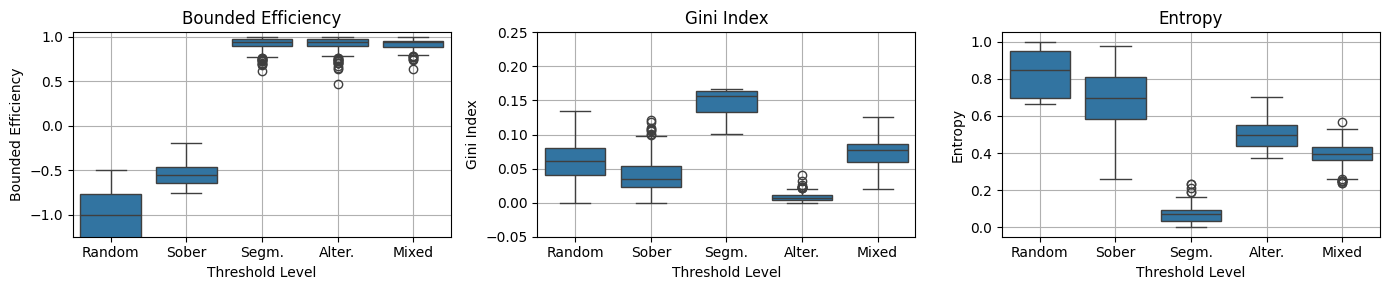

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3), tight_layout=True)

sns.boxplot(
    data=df_measures,
    x="kind",
    y="bounded_efficiency",
    ax=ax[0],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
ax[0].set_ylim(-1.25, 1.05)
ax[0].set_title(r"Bounded Efficiency")
ax[0].set_xlabel("Threshold Level")
ax[0].set_ylabel("Bounded Efficiency")

sns.boxplot(
    data=df_measures,
    x="kind",
    y="gini_index",
    ax=ax[1],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
ax[1].set_ylim(-0.05, 0.25)
ax[1].set_title(r"Gini Index")
ax[1].set_xlabel("Threshold Level")
ax[1].set_ylabel("Gini Index")

sns.boxplot(
    data=df_measures,
    x="kind",
    y="entropy",
    ax=ax[2],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
ax[2].set_ylim(-0.05, 1.05)
ax[2].set_title(r"Entropy")
ax[2].set_xlabel("Threshold Level")
ax[2].set_ylabel("Entropy")

for ax_ in ax:
    ax_.grid()

plt.show()
fig.savefig(PATHS['exploratory_figures'] / 'measurements.png', dpi=300)

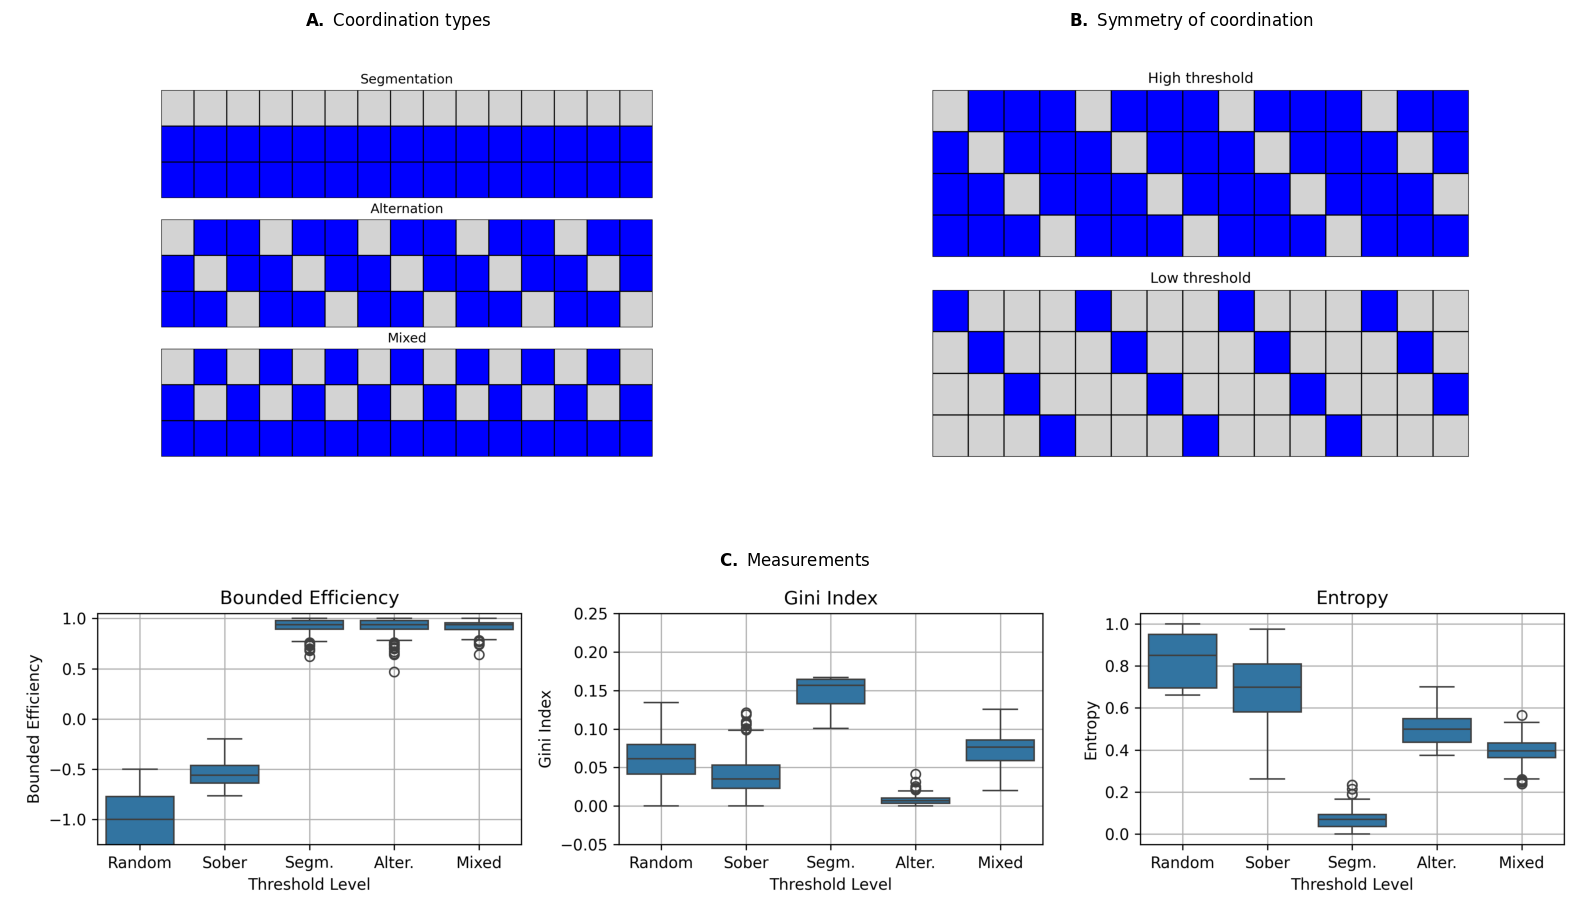

In [8]:
fig = plt.figure(figsize=(16, 10))

# Create a 2x2 grid
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom row (spanning)
ax3 = fig.add_subplot(gs[1, :])

ax1.imshow(plt.imread(PATHS['exploratory_figures'] / 'Coordination_types.png'))
ax1.set_title(r'$\bf{A.}$ Coordination types')

ax2.imshow(plt.imread(PATHS['exploratory_figures'] / 'Symmetry_of_coordination.png'))
ax2.set_title(r'$\bf{B.}$ Symmetry of coordination')

ax3.imshow(plt.imread(PATHS['exploratory_figures'] / 'measurements.png'))
ax3.set_title(r'$\bf{C.}$ Measurements')

for ax in [ax1, ax2, ax3]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(PATHS['exploratory_figures'] / 'Fig1.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

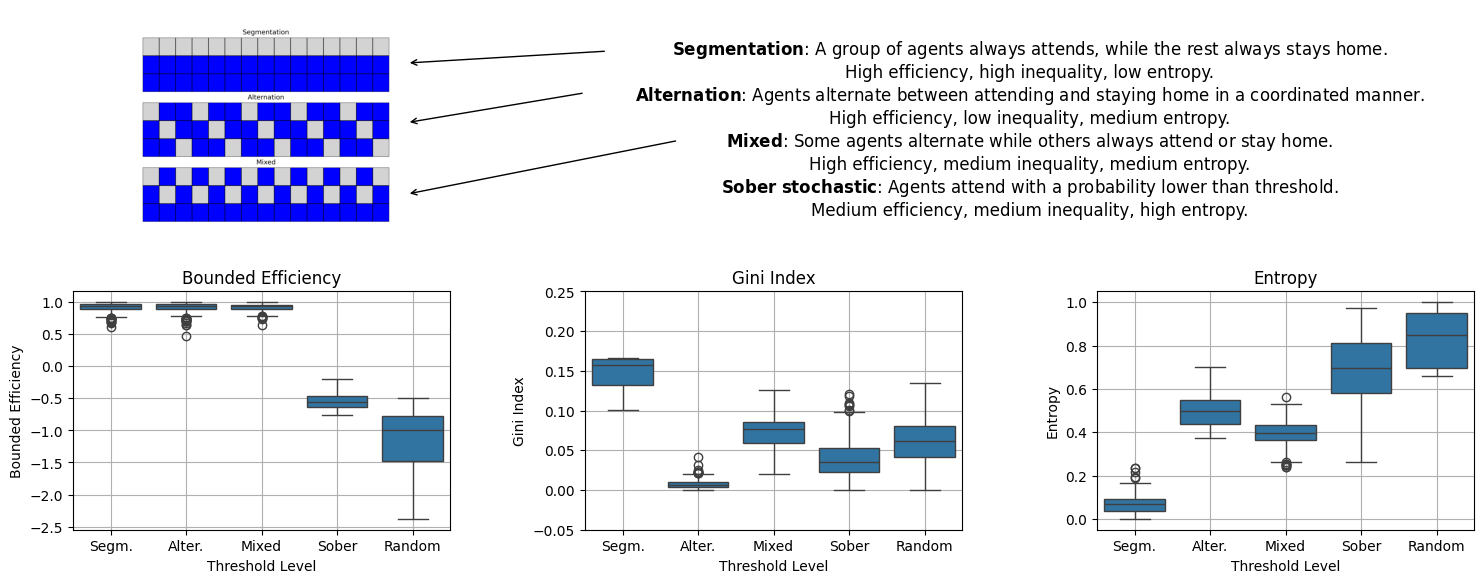

In [14]:
fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(2, 3)

# Subplots
ax_top_left = fig.add_subplot(gs[0, 0])
ax_bot_left   = fig.add_subplot(gs[1, 0])
ax_bot_mid   = fig.add_subplot(gs[1, 1])
ax_bot_right = fig.add_subplot(gs[1, 2])

# Left plot spanning both rows
ax_top_right = fig.add_subplot(gs[0, 1:])

text = r"""
$\bf{Segmentation}$: A group of agents always attends, while the rest always stays home.
High efficiency, high inequality, low entropy.
$\bf{Alternation}$: Agents alternate between attending and staying home in a coordinated manner.
High efficiency, low inequality, medium entropy.
$\bf{Mixed}$: Some agents alternate while others always attend or stay home.
High efficiency, medium inequality, medium entropy.
$\bf{Sober}$ $\bf{stochastic}$: Agents attend with a probability lower than threshold.
Medium efficiency, medium inequality, high entropy.
"""

# Add text to the top-right subplot
ax_top_right.text(
    0.5, 0.5,
    text,
    ha='center', va='center',
    fontsize=12
)
ax_top_right.axis('off')

ax_top_left.imshow(plt.imread(PATHS['exploratory_figures'] / 'Coordination_types.png'))
ax_top_left.axis('off')

sns.boxplot(
    data=df_measures,
    x="kind",
    y="bounded_efficiency",
    ax=ax_bot_left,
    order=["Segm.", "Alter.", "Mixed", "Sober", "Random"],
)
# ax_bot_left.set_ylim(-1.45, 1.05)
ax_bot_left.set_title(r"Bounded Efficiency")
ax_bot_left.set_xlabel("Threshold Level")
ax_bot_left.set_ylabel("Bounded Efficiency")
ax_bot_left.grid()

sns.boxplot(
    data=df_measures,
    x="kind",
    y="gini_index",
    ax=ax_bot_mid,
    order=["Segm.", "Alter.", "Mixed", "Sober", "Random"],
)
ax_bot_mid.set_ylim(-0.05, 0.25)
ax_bot_mid.set_title(r"Gini Index")
ax_bot_mid.set_xlabel("Threshold Level")
ax_bot_mid.set_ylabel("Gini Index")
ax_bot_mid.grid()

sns.boxplot(
    data=df_measures,
    x="kind",
    y="entropy",
    ax=ax_bot_right,
    order=["Segm.", "Alter.", "Mixed", "Sober", "Random"],
)
ax_bot_right.set_ylim(-0.05, 1.05)
ax_bot_right.set_title(r"Entropy")
ax_bot_right.set_xlabel("Threshold Level")
ax_bot_right.set_ylabel("Entropy")
ax_bot_right.grid()

plt.annotate(
    '',
    xy=(0.025, 0.825), xycoords='axes fraction',
    xytext=(-0.2, 0.775), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)
plt.annotate(
    '',
    xy=(0.00, 0.65), xycoords='axes fraction',
    xytext=(-0.2, 0.525), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)
plt.annotate(
    '',
    xy=(0.105, 0.45), xycoords='axes fraction',
    xytext=(-0.2, 0.225), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)

plt.tight_layout()
plt.show()

In [17]:
df_measures[df_measures['bounded_efficiency'] < -1.5]

,threshold,num_agents,id_sim,kind,bounded_efficiency,gini_index,entropy,conditional_entropy,min_entropy,efficiency
30,0.34,4,4-0.34-0.01-random-0,random,-2.20,0.027778,0.968317,0.421068,0.020833,-0.5500
31,0.34,4,4-0.34-0.01-random-1,random,-2.02,0.022727,0.944997,0.428308,0.031250,-0.5050
32,0.34,4,4-0.34-0.01-random-10,random,-2.00,0.075000,0.943834,0.383476,0.080780,-0.5000
33,0.34,4,4-0.34-0.01-random-11,random,-1.76,0.022321,0.945496,0.411883,0.035182,-0.4400
34,0.34,4,4-0.34-0.01-random-12,random,-2.00,0.110000,0.927818,0.440208,0.020833,-0.5000
...,...,...,...,...,...,...,...,...,...,...
355,0.34,8,8-0.34-0.01-random-5,random,-1.98,0.106436,0.683595,0.022334,0.000000,-0.4950
356,0.34,8,8-0.34-0.01-random-6,random,-2.02,0.093434,0.670482,0.035714,0.000000,-0.5050
357,0.34,8,8-0.34-0.01-random-7,random,-2.13,0.050134,0.680482,0.025510,0.000000,-0.5325
358,0.34,8,8-0.34-0.01-random-8,random,-1.97,0.073276,0.680482,0.025510,0.000000,-0.4925
